In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [2]:
students_path = "survey_students.xlsx"
supervisors_path = "survey_supervisors.xlsx"

students_df = pd.read_excel(students_path)
supervisors_df = pd.read_excel(supervisors_path)

# Preview structure
students_df.columns, supervisors_df.columns

(Index(['ID', 'Каким способом вы нашли команду?',
        'Были ли у вас сложности в поиске команды? Если были, то какие? (можно выбрать несколько вариантов)',
        'Вы искали команду или команда нашла вас?',
        'Как долго вы искали команду?', 'Ваши ожидания от команды оправдались?',
        'Какие критерии были для вас важны при выборе команды? (можно выбрать несколько вариантов)',
        'Как долго вы искали профессора?',
        'Каким способом вы нашли профессора?',
        'Были ли у вас сложности с выбором профессора? Если были, то какие? (можно выбрать несколько вариантов)',
        'Вы довольны выбором профессора?',
        'Как долго ваша команда выбирала тему диплома?',
        'Вы довольны выбранной темой? ',
        'Вы удовлетворены нынешним процессом поиска и подбора команды и руководителя?'],
       dtype='object'),
 Index(['ID',
        ' Как, по вашему мнению, студенты чаще всего выбирают Вас в научные руководители?  (можно выбрать несколько вариантов) ',
    

In [3]:
students_df.rename(columns={
    'Каким способом вы нашли команду?': 'Team_Search_Method',
    'Были ли у вас сложности в поиске команды? Если были, то какие? (можно выбрать несколько вариантов)': 'Team_Search_Difficulties',
    'Вы искали команду или команда нашла вас?': 'Team_Initiative',
    'Как долго вы искали команду?': 'Team_Search_Duration',
    'Какие критерии были для вас важны при выборе команды?\xa0(можно выбрать несколько вариантов)': 'Team_Criteria',
    'Ваши ожидания от команды оправдались?': 'Team_Satisfaction',
    'Как долго вы искали профессора?': 'Supervisor_Search_Duration',
    'Каким способом вы нашли профессора?': 'Supervisor_Search_Method',
    'Были ли у вас сложности с выбором профессора? Если были, то какие? (можно выбрать несколько вариантов)': 'Supervisor_Selection_Difficulties',
    'Вы довольны выбором профессора?': 'Supervisor_Satisfaction',
    'Как долго ваша команда выбирала тему диплома?': 'Topic_Search_Duration',
    'Вы довольны выбранной темой?\xa0': 'Topic_Satisfaction',
    'Вы удовлетворены нынешним процессом поиска и подбора команды и руководителя?': 'Satisfaction'
}, inplace=True)

display(students_df)

,ID,Team_Search_Method,Team_Search_Difficulties,Team_Initiative,Team_Search_Duration,Team_Satisfaction,Team_Criteria,Supervisor_Search_Duration,Supervisor_Search_Method,Supervisor_Selection_Difficulties,Supervisor_Satisfaction,Topic_Search_Duration,Topic_Satisfaction,Satisfaction
0,1,Личные знакомства;,Не было;,Совместный поиск с друзьями,Не искал,Да,Личное знакомство с участниками,1-2 недели,Репутация профессора,Не было;,Да,Месяц,Да,Да
1,2,Личные знакомства;,"Не знал, где искать команду;Не мог/-ла найти л...",Совместный поиск с друзьями,Больше месяца,Нет,Личное знакомство с участниками,Больше месяца,Объявления от деканата,"Не знал/-а, как искать профессора;Желаемые про...",Нет,Больше месяца,Нет,Нет
2,3,Личные знакомства;,Мои знакомые уже были в командах;Меня не приня...,Меня пригласили,Больше месяца,Частично,Общий интерес к теме проекта,Меньше недели,Объявления от деканата,Не было;,"Скорее да, чем нет",Меньше недели,"Скорее да, чем нет",Нейтрально
3,4,Личные знакомства;,Не было;,Сам/-а искал/-а,Месяц,Да,Личное знакомство с участниками,1-2 недели,Рекомендации старших студентов,Не было;,Да,1-2 недели,Да,Да
4,5,Личные знакомства;,Не было;,Совместный поиск с друзьями,Меньше недели,Частично,"Уровень знаний участников, уровень GPA",Меньше недели,Объявления от деканата,"Не знал/-а, как искать профессора;","Скорее да, чем нет",Меньше недели,"Скорее да, чем нет",Нет
5,6,Личные знакомства;,Не было;,Меня пригласили,Меньше недели,Да,Общий интерес к теме проекта,Меньше недели,Репутация профессора,Не было;,"Скорее да, чем нет",1-2 недели,Да,Да
6,7,Объявления в чатах;Случайный подбор;,Не мог/-ла найти людей с нужными навыками;Мои ...,Меня пригласили,1-2 недели,Частично,"Уровень знаний участников, уровень GPA",1-2 недели,Обучался в дисциплинах преподавателя,Желаемые профессора уже были заняты;Не все пре...,"Скорее да, чем нет",1-2 недели,Нет,Нейтрально
7,8,Личные знакомства;,Не было;,Сам/-а искал/-а,Меньше недели,Да,Личное знакомство с участниками,Меньше недели,Объявления от деканата,Не было;,Да,1-2 недели,Да,Да
8,9,Личные знакомства;,"Команды набирались слишком быстро;Не знал, где...",Меня пригласили,1-2 недели,Да,"Репутация, рекомендации участников",1-2 недели,Репутация профессора,Не было;,Да,1-2 недели,Да,Нет
9,10,Объявления в чатах;,Мои знакомые уже были в командах;Команды набир...,Меня пригласили,1-2 недели,Да,"Уровень знаний участников, уровень GPA",1-2 недели,Обучался в дисциплинах преподавателя,Не было;,"Скорее нет, чем да",Месяц,"Скорее да, чем нет",Нейтрально


In [4]:
supervisors_df.rename(columns={
    '\xa0Как, по вашему мнению, студенты чаще всего выбирают Вас в научные руководители?\xa0\xa0(можно выбрать несколько вариантов)\xa0': 'Student_Choice_Factors',
    'Какие, по вашему мнению, основные трудности возникают при подборе научного руководителя? (можно выбрать несколько вариантов)': 'Supervisor_Selection_Difficulties',
    'Как, по вашему мнению, из ниже перечисленного, можно улучшить процесс подбора научного руководителя?': 'Improvement_Suggestions',
    'Чувствуете ли вы чрезмерную нагрузку из-за большого количества дипломников?': 'Overload_Level',
    'Считаете ли вы процесс подбора научного руководителя эффективным?': 'Supervisor_Satisfaction',
    'Как, по вашему мнению, должен выглядеть процесс выбора темы дипломного проекта?': 'Topic_Selection_Preference',
    'Отметьте, что, по вашему мнению, входит в основные критерии выбора темы диплома:': 'Topic_Criteria',
    'Вы удовлетворены тем, как в текущей системе происходит выбор темы дипломной работы?': 'Topic_Satisfaction',
    'Какие, по вашему мнению, проблемы чаще всего возникают при командной работе над дипломным проектом?\xa0(можно выбрать несколько вариантов)': 'Teamwork_Difficulties',
    'Что влияет на Ваше согласие работать с командой студентов?': 'Team_Acceptance_Criteria',
    'Случались ли у вас ситуации, когда студенту и вам было сложно сработаться друг с другом? Если да, в чем были сложности?': 'Student_Interaction_Issues',
    'Принимаете ли вы студентов только по темам, которые соответствуют вашему профилю или текущим исследованиям?': 'Profile_Strictness',
    'Вы удовлетворены тем, как формируются и работают студенческие команды?': 'Team_Satisfaction',
    'Вы удовлетворены нынешней системой поиска и подбора команды и руководителя?': 'Satisfaction'
}, inplace=True)

display(supervisors_df)

,ID,Student_Choice_Factors,Supervisor_Selection_Difficulties,Improvement_Suggestions,Overload_Level,Supervisor_Satisfaction,Topic_Selection_Preference,Topic_Criteria,Topic_Satisfaction,Teamwork_Difficulties,Team_Acceptance_Criteria,Student_Interaction_Issues,Profile_Strictness,Team_Satisfaction,Satisfaction
0,1,Область профессиональных интересов;,Сложности в организации взаимодействия после в...,Организовать консультационные встречи перед вы...,"Нет, количество дипломников нормальное","Скорее да, чем нет","Должен быть компромисс: студенты предлагают, п...",Актуальность и востребованность темы ;Соответ...,"Скорее да, чем нет",Неравномерное распределение обязанностей;Пробл...,Идейность студентов;GPA;Профессиональные навык...,Отсутствие интереса к теме диплома;Низкий уров...,"Да, я работаю только с теми проектами, которые...","Скорее нет, чем да",Нейтрально
1,2,Студенты обучались у меня;Область профессионал...,Перегруженность руководителей;Студенты плохо п...,Организовать консультационные встречи перед вы...,"Иногда, но в целом справляюсь",Нет,"Должен быть компромисс: студенты предлагают, п...",Соответствие профессиональным интересам студен...,"Скорее да, чем нет",Неравномерное распределение обязанностей;Недос...,Совместимость с моим профилем и интересами;Иде...,Не было;,"Да, я работаю только с теми проектами, которые...","Скорее нет, чем да",Нейтрально
2,3,Студенты обучались у меня;Занятость руководите...,Недостаток информации о специализации преподав...,Создать открытую базу данных с единым оформлен...,"Иногда, но в целом справляюсь",Нет,"Должен быть компромисс: студенты предлагают, п...",Возможность практического применения ;Реалист...,"Скорее нет, чем да",Проблемы с координацией и дедлайнами;Недостато...,Идейность студентов;Профессиональные навыки ;,Отсутствие интереса к теме диплома;Недостаточн...,"В большинстве случаев, но могу взять студента ...","Скорее да, чем нет",Нет
3,4,Область профессиональных интересов;Студенты об...,Недостаток информации о специализации преподав...,Организовать консультационные встречи перед вы...,"Нет, количество дипломников нормальное","Скорее да, чем нет","Должен быть компромисс: студенты предлагают, п...",Актуальность и востребованность темы ;Возможн...,"Скорее да, чем нет",Проблемы с координацией и дедлайнами;Недостато...,Профессиональные навыки ;,Низкий уровень подготовки студента;,"Нет, я готов руководить студентами по широкому...","Скорее нет, чем да",Нейтрально
4,5,Область профессиональных интересов;Занятость р...,Чрезмерная нагрузка на некоторых преподавателе...,руководитель пишет примерные темы которые он м...,"Нет, количество дипломников нормальное",Да,"Должен быть компромисс: студенты предлагают, п...",Актуальность и востребованность темы ;Реалист...,Да,Неравномерное распределение обязанностей;Пробл...,Идейность студентов;Дисциплинированность ;Проф...,Недостаточная самостоятельность студента;Пробл...,"Да, я работаю только с теми проектами, которые...",Да,Да
5,6,Область профессиональных интересов;Студенты об...,Перегруженность руководителей;Студенты плохо п...,Организовать консультационные встречи перед вы...,"Иногда, но в целом справляюсь","Скорее да, чем нет","Должен быть компромисс: студенты предлагают, п...",Соответствие профессиональным интересам студен...,"Скорее да, чем нет",Неравномерное распределение обязанностей;Недос...,Идейность студентов;Профессиональные навыки ;Д...,Низкий уровень подготовки студента;Недостаточн...,"Да, я работаю только с теми проектами, которые...","Скорее да, чем нет",Нейтрально
6,7,Рекомендации других студентов или выпускников;...,Недостаток информации о специализации преподав...,Организовать консультационные встречи перед вы...,"Да, нагрузка значительно выше оптимальной","Скорее да, чем нет","Должен быть компромисс: студенты предлагают, п...","требование к навыкам студентов, которым мы обу...","Скорее да, чем нет",Проблемы с координацией и дедлайнами;Недостато...,Дисциплинированность ;Совместимость с моим про...,Низкий уровень подготовки студента;,"Нет

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Глобальные настройки для всех графиков
plt.rcParams.update({
    'axes.titlesize': 18,       # Размер заголовка
    'axes.labelsize': 16,       # Размер подписей осей
    'xtick.labelsize': 16,      # Размер подписей по оси X
    'ytick.labelsize': 16,      # Размер подписей по оси Y
    'legend.fontsize': 14,      # Размер шрифта легенды, если будет
    'figure.figsize': (10, 6)   # Размер графика по умолчанию
})


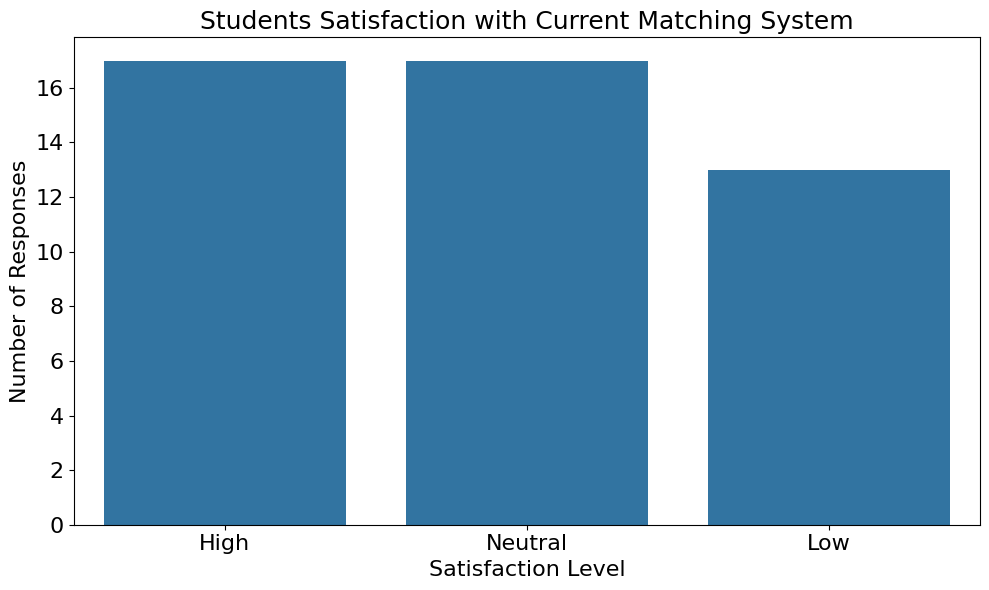

In [22]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=students_df,
    x='Satisfaction',
    order=['Да', 'Нейтрально', 'Нет']
)

# Увеличиваем надписи на оси X
ax.set_xticklabels(['High', 'Neutral', 'Low'])

# Увеличиваем надписи на оси Y (числа)
ax.tick_params(axis='y')

# Увеличиваем заголовок и подписи осей
plt.title("Students Satisfaction with Current Matching System")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Responses")

plt.tight_layout()
plt.savefig('students_satisfaction.png', dpi=300)
plt.show()

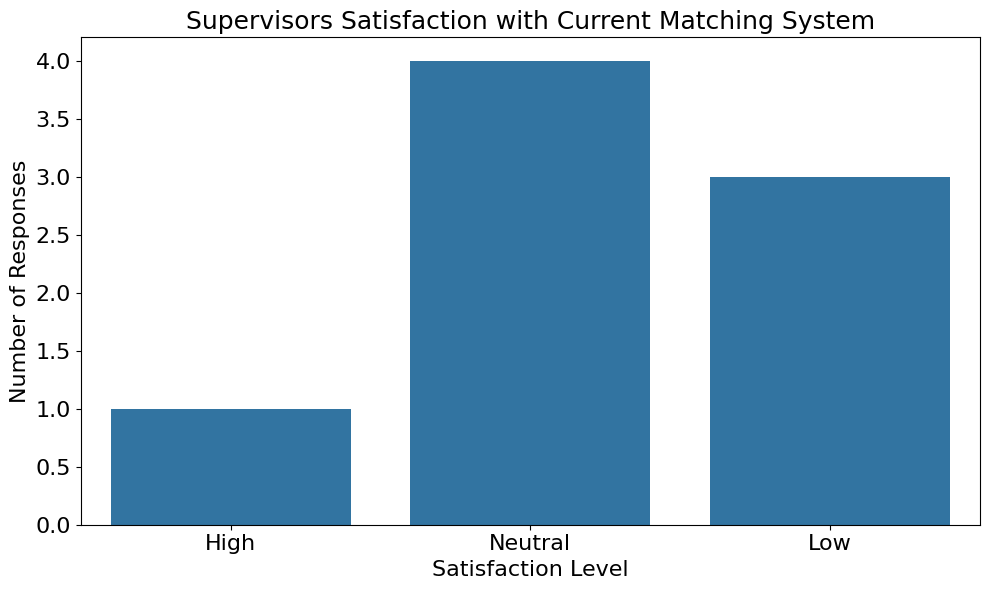

In [23]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=supervisors_df,
    x='Satisfaction',
    order=['Да', 'Нейтрально', 'Нет']
)
ax.set_xticklabels(['High', 'Neutral', 'Low'])

plt.title("Supervisors Satisfaction with Current Matching System")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Responses")
plt.tight_layout()
plt.savefig('supervisors_satisfaction.png', dpi=300)
plt.show()

In [13]:
scale_map = {'Нет': 0, 'Скорее нет, чем да': 0.25, 'Нейтрально': 0.5, 'Частично': 0.5, 'Скорее да, чем нет': 0.75, 'Да': 1}

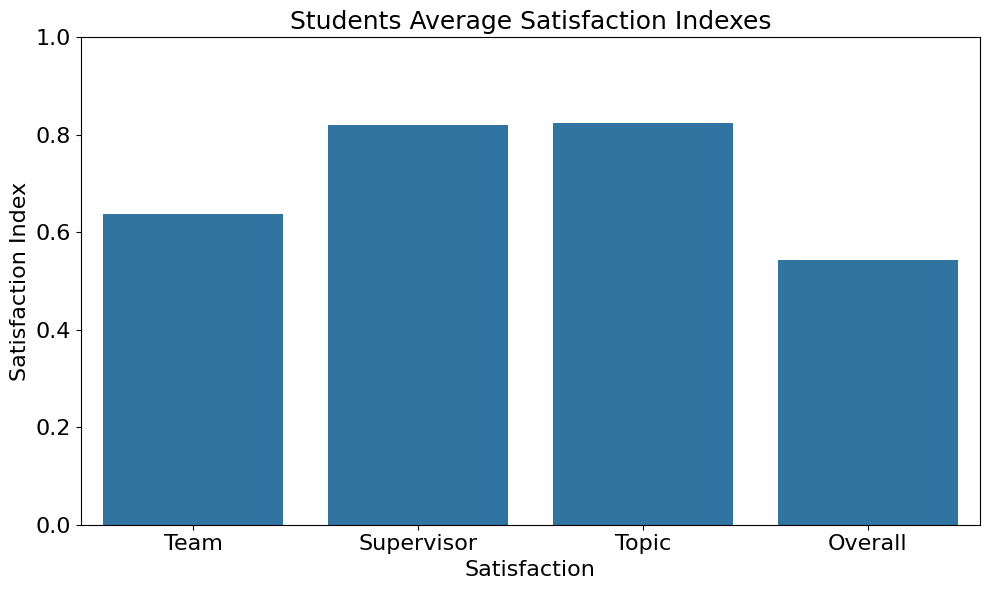

In [24]:
students_satisfation = students_df.copy()

students_satisfation['Team'] = students_satisfation['Team_Satisfaction'].map(scale_map)
students_satisfation['Supervisor'] = students_satisfation['Supervisor_Satisfaction'].map(scale_map)
students_satisfation['Topic'] = students_satisfation['Topic_Satisfaction'].map(scale_map)
students_satisfation['Overall'] = students_satisfation['Satisfaction'].map(scale_map)
students_satisfaction_indexes = students_satisfation[['Team', 'Supervisor', 'Topic', 'Overall']].mean().rename("Student_Mean")

plt.figure(figsize=(10, 6))
sns.barplot(x=students_satisfaction_indexes.index, y=students_satisfaction_indexes.values)
plt.title("Students Average Satisfaction Indexes")
plt.xlabel("Satisfaction")
plt.ylabel("Satisfaction Index")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('students_satisfaction_indexes.png', dpi=300)
plt.show()

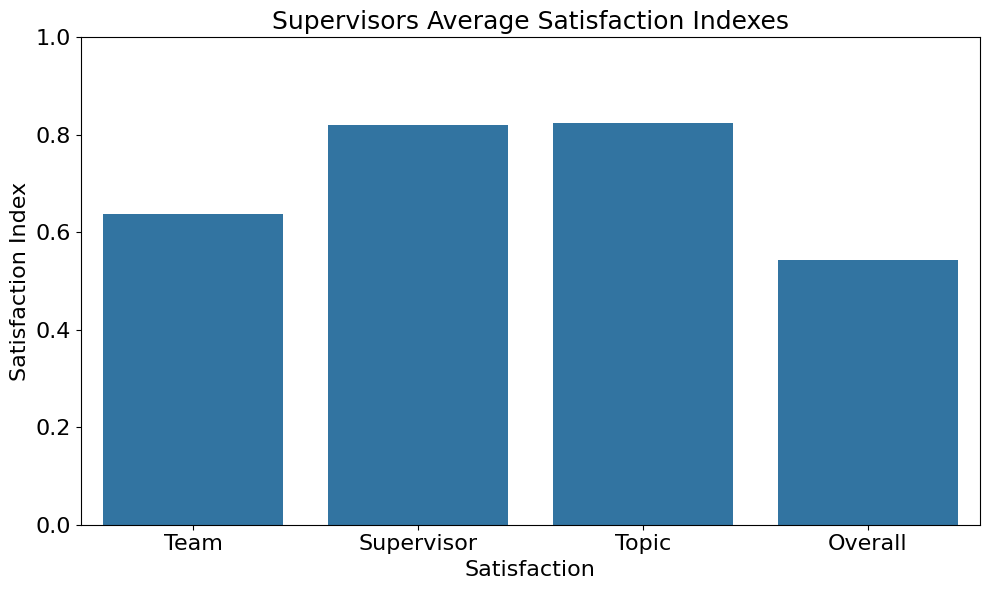

In [25]:
supervisors_satisfation = students_df.copy()

supervisors_satisfation['Team'] = supervisors_satisfation['Team_Satisfaction'].map(scale_map)
supervisors_satisfation['Supervisor'] = supervisors_satisfation['Supervisor_Satisfaction'].map(scale_map)
supervisors_satisfation['Topic'] = supervisors_satisfation['Topic_Satisfaction'].map(scale_map)
supervisors_satisfation['Overall'] = supervisors_satisfation['Satisfaction'].map(scale_map)
supervisors_satisfaction_indexes = supervisors_satisfation[['Team', 'Supervisor', 'Topic', 'Overall']].mean().rename("Student_Mean")

plt.figure(figsize=(10, 6))
sns.barplot(x=supervisors_satisfaction_indexes.index, y=supervisors_satisfaction_indexes.values)
plt.title("Supervisors Average Satisfaction Indexes")
plt.xlabel("Satisfaction")
plt.ylabel("Satisfaction Index")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('supervisors_satisfaction_indexes.png', dpi=300)
plt.show()

In [26]:
students_blocks_score = students_df.copy()

for col in ['Team_Satisfaction', 'Supervisor_Satisfaction', 'Topic_Satisfaction', 'Satisfaction']:
    students_blocks_score[col] = students_blocks_score[col].astype(str).str.strip().map(scale_map)

# TEAM
students_blocks_score['Team_Search_Method'] = students_blocks_score['Team_Search_Method'].apply(
    lambda x: 0.2 * len(str(x).split(';')) if pd.notna(x) else 0
)

students_blocks_score['Team_Search_Difficulties'] = students_blocks_score['Team_Search_Difficulties'].apply(
    lambda x: 0 if 'Не было' in str(x) else 0.14 * len(str(x).split(';')) if pd.notna(x) else 0
)

students_blocks_score['Team_Initiative'] = students_blocks_score['Team_Initiative'].apply(
    lambda x: 0.3 * len(str(x).split(';')) if pd.notna(x) else 0
)

students_blocks_score['Team_Criteria'] = students_blocks_score['Team_Criteria'].apply(
    lambda x: 0.2 * len(str(x).split(';')) if pd.notna(x) else 0
)

team_duration_map = {
    'Не искал': 1.0, 'Меньше недели': 0.8, '1-2 недели': 0.6,
    'Месяц': 0.4, 'Больше месяца': 0.2, 'Не нашел': 0.0
}
students_blocks_score['Team_Search_Duration'] = students_blocks_score['Team_Search_Duration'].map(team_duration_map).fillna(0)

# SUPERVISORS
supervisor_duration_map = {
    'Меньше недели': 1.0, '1-2 недели': 0.75, 'Месяц': 0.5, 'Больше месяца': 0.25
}
students_blocks_score['Supervisor_Search_Duration'] = students_blocks_score['Supervisor_Search_Duration'].map(supervisor_duration_map).fillna(0)

students_blocks_score['Supervisor_Selection_Difficulties'] = students_blocks_score['Supervisor_Selection_Difficulties'].apply(
    lambda x: 0 if 'Не было' in str(x) else 0.14 * len(str(x).split(';')) if pd.notna(x) else 0
)

students_blocks_score['Supervisor_Search_Method'] = students_blocks_score['Supervisor_Search_Method'].apply(
    lambda x: 0.2 * len(str(x).split(';')) if pd.notna(x) else 0
)

# TOPIC
topic_duration_map = {
    'Меньше недели': 1.0, '1-2 недели': 0.75, 'Месяц': 0.5, 'Больше месяца': 0.25
}
students_blocks_score['Topic_Search_Duration'] = students_blocks_score['Topic_Search_Duration'].map(topic_duration_map).fillna(0)

display(students_blocks_score)

,ID,Team_Search_Method,Team_Search_Difficulties,Team_Initiative,Team_Search_Duration,Team_Satisfaction,Team_Criteria,Supervisor_Search_Duration,Supervisor_Search_Method,Supervisor_Selection_Difficulties,Supervisor_Satisfaction,Topic_Search_Duration,Topic_Satisfaction,Satisfaction
0,1,0.4,0.00,0.3,1.0,1.0,0.2,0.75,0.2,0.00,1.00,0.50,1.00,1.0
1,2,0.4,0.56,0.3,0.2,0.0,0.2,0.25,0.2,0.98,0.00,0.25,0.00,0.0
2,3,0.4,0.42,0.3,0.2,0.5,0.2,1.00,0.2,0.00,0.75,1.00,0.75,0.5
3,4,0.4,0.00,0.3,0.4,1.0,0.2,0.75,0.2,0.00,1.00,0.75,1.00,1.0
4,5,0.4,0.00,0.3,0.8,0.5,0.2,1.00,0.2,0.28,0.75,1.00,0.75,0.0
5,6,0.4,0.00,0.3,0.8,1.0,0.2,1.00,0.2,0.00,0.75,0.75,1.00,1.0
6,7,0.6,0.56,0.3,0.6,0.5,0.2,0.75,0.2,0.42,0.75,0.75,0.00,0.5
7,8,0.4,0.00,0.3,0.8,1.0,0.2,1.00,0.2,0.00,1.00,0.75,1.00,1.0
8,9,0.4,0.56,0.3,0.6,1.0,0.2,0.75,0.2,0.00,1.00,0.75,1.00,0.0
9,10,0.4,0.42,0.3,0.6,1.0,0.2,0.75,0.2,0.00,0.25,0.50,0.75,0.5


In [27]:
supervisors_blocks_score = supervisors_df.copy()

for col in ['Supervisor_Satisfaction', 'Topic_Satisfaction', 'Team_Satisfaction', 'Satisfaction']:
    supervisors_blocks_score[col] = (
        supervisors_blocks_score[col]
        .astype(str)
        .str.strip()
        .map(lambda x: scale_map.get(x, 0.0))
    )

# SUPERVISORS
supervisors_blocks_score['Student_Choice_Factors'] = supervisors_blocks_score['Student_Choice_Factors'].apply(
    lambda x: 0.16 * len(str(x).split(';')) if pd.notna(x) else 0
)

supervisors_blocks_score['Supervisor_Selection_Difficulties'] = supervisors_blocks_score['Supervisor_Selection_Difficulties'].apply(
    lambda x: 0 if 'Не было' in str(x) else 0.13 * len(str(x).split(';')) if pd.notna(x) else 0
)

supervisors_blocks_score['Overload_Level'] = supervisors_blocks_score['Overload_Level'].map({
    'Да, нагрузка значительно выше оптимальной': 0.0,
    'Иногда, но в целом справляюсь': 0.5,
    'Нет, количество дипломников нормальное': 1.0
}).fillna(0)

# TOPIC
supervisors_blocks_score['Topic_Criteria'] = supervisors_blocks_score['Topic_Criteria'].apply(
    lambda x: 0.16 * len(str(x).split(';')) if pd.notna(x) else 0
)

supervisors_blocks_score['Topic_Selection_Preference'] = supervisors_blocks_score['Topic_Selection_Preference'].map({
    'Темы должны предлагаться преподавателями': 0.25,
    'Темы должны предлагаться студентами': 0.25,
    'Должен быть компромисс: студенты предлагают, профессор утверждает (или отклоняет)': 0.5
}).fillna(0)

supervisors_blocks_score['Profile_Strictness'] = supervisors_blocks_score['Profile_Strictness'].map({
    'Да, я работаю только с теми проектами, которые соответствуют моей области исследований': 1.0,
    'В большинстве случаев, но могу взять студента с другой темой при достаточной мотивации': 0.5,
    'Нет, я готов руководить студентами по широкому кругу тем': 0.0
}).fillna(0)

supervisors_blocks_score['Improvement_Suggestions'] = supervisors_blocks_score['Improvement_Suggestions'].apply(
    lambda x: 0.2 * len(str(x).split(';')) if pd.notna(x) else 0
)

# TEAM
supervisors_blocks_score['Teamwork_Difficulties'] = supervisors_blocks_score['Teamwork_Difficulties'].apply(
    lambda x: 0.2 * len(str(x).split(';')) if pd.notna(x) else 0
)

supervisors_blocks_score['Team_Acceptance_Criteria'] = supervisors_blocks_score['Team_Acceptance_Criteria'].apply(
    lambda x: 0.14 * len(str(x).split(';')) if pd.notna(x) else 0
)

supervisors_blocks_score['Student_Interaction_Issues'] = supervisors_blocks_score['Student_Interaction_Issues'].apply(
    lambda x: 1 if 'Не было' in str(x) else 0.2 * len(str(x).split(';')) if pd.notna(x) else 0
)


display(supervisors_blocks_score)

,ID,Student_Choice_Factors,Supervisor_Selection_Difficulties,Improvement_Suggestions,Overload_Level,Supervisor_Satisfaction,Topic_Selection_Preference,Topic_Criteria,Topic_Satisfaction,Teamwork_Difficulties,Team_Acceptance_Criteria,Student_Interaction_Issues,Profile_Strictness,Team_Satisfaction,Satisfaction
0,1,0.32,0.39,0.8,1.0,0.75,0.5,0.96,0.75,0.8,0.84,1.0,1.0,0.25,0.5
1,2,0.48,0.39,0.6,0.5,0.00,0.5,0.48,0.75,0.6,0.42,1.0,1.0,0.25,0.5
2,3,0.48,0.65,0.8,0.5,0.00,0.5,0.64,0.25,0.6,0.42,0.8,0.5,0.75,0.0
3,4,0.48,0.39,0.6,1.0,0.75,0.5,0.48,0.75,0.6,0.28,0.4,0.0,0.25,0.5
4,5,0.48,0.39,0.4,1.0,1.00,0.5,0.64,1.00,0.8,0.56,0.6,1.0,1.00,1.0
5,6,0.64,0.52,0.6,0.5,0.75,0.5,0.48,0.75,0.6,0.56,1.0,1.0,0.75,0.5
6,7,0.64,1.04,0.6,0.0,0.75,0.5,0.32,0.75,0.6,0.70,0.4,0.0,0.75,0.0
7,8,0.64,0.78,0.6,0.5,1.00,0.5,0.96,1.00,1.0,0.70,1.0,0.5,0.75,0.0


In [28]:
students_block_features = {
    'Team_Satisfaction': [
        'Team_Search_Method', 'Team_Search_Difficulties',
        'Team_Search_Duration'
    ],
    'Supervisor_Satisfaction': [
        'Supervisor_Search_Duration', 'Supervisor_Selection_Difficulties'
    ],
    'Topic_Satisfaction': ['Topic_Search_Duration']
}

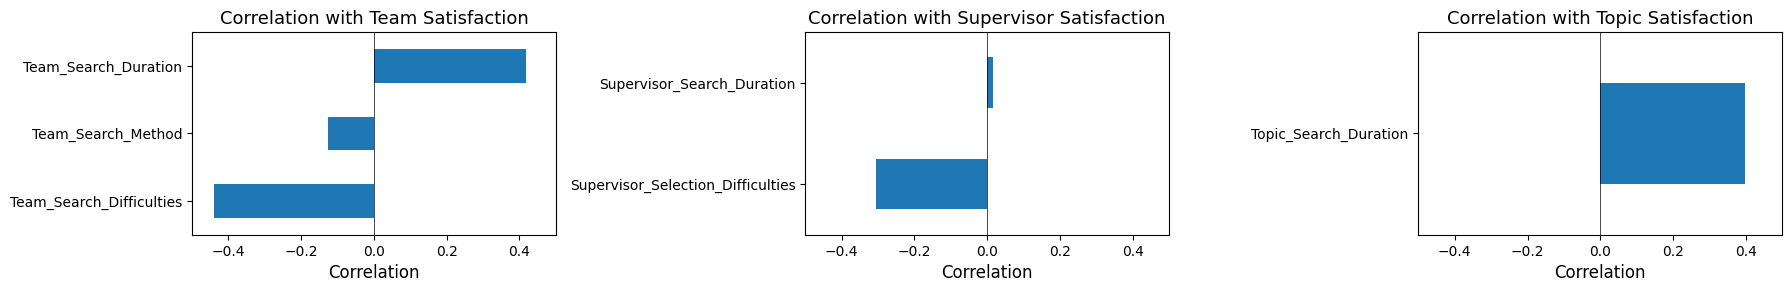

Team Satisfaction:
Team_Search_Duration: 0.418
Team_Search_Method: -0.125
Team_Search_Difficulties: -0.439

Supervisor Satisfaction:
Supervisor_Search_Duration: 0.017
Supervisor_Selection_Difficulties: -0.307

Topic Satisfaction:
Topic_Search_Duration: 0.398



In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 3), sharey=False)
for ax, (target, features) in zip(axes, students_block_features.items()):
    corrs = students_blocks_score[features + [target]].corr()[target].drop(target)
    corrs.sort_values().plot(kind='barh', ax=ax, width=0.5)
    ax.set_title(f"Correlation with {target.replace('_', ' ')}", fontsize=13)
    ax.set_xlim(-0.5, 0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Correlation', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)  
    ax.tick_params(axis='x', labelsize=10)
    
plt.tight_layout(pad=1) 
plt.savefig('students_correlation_blocks.png', dpi=300)
plt.show()

for target, features in students_block_features.items():
    corrs = students_blocks_score[features + [target]].corr()[target].drop(target).sort_values(ascending=False)
    
    print(f"{target.replace('_', ' ')}:")
    for param, val in corrs.items():
        print(f"{param}: {val:.3f}")
    print()

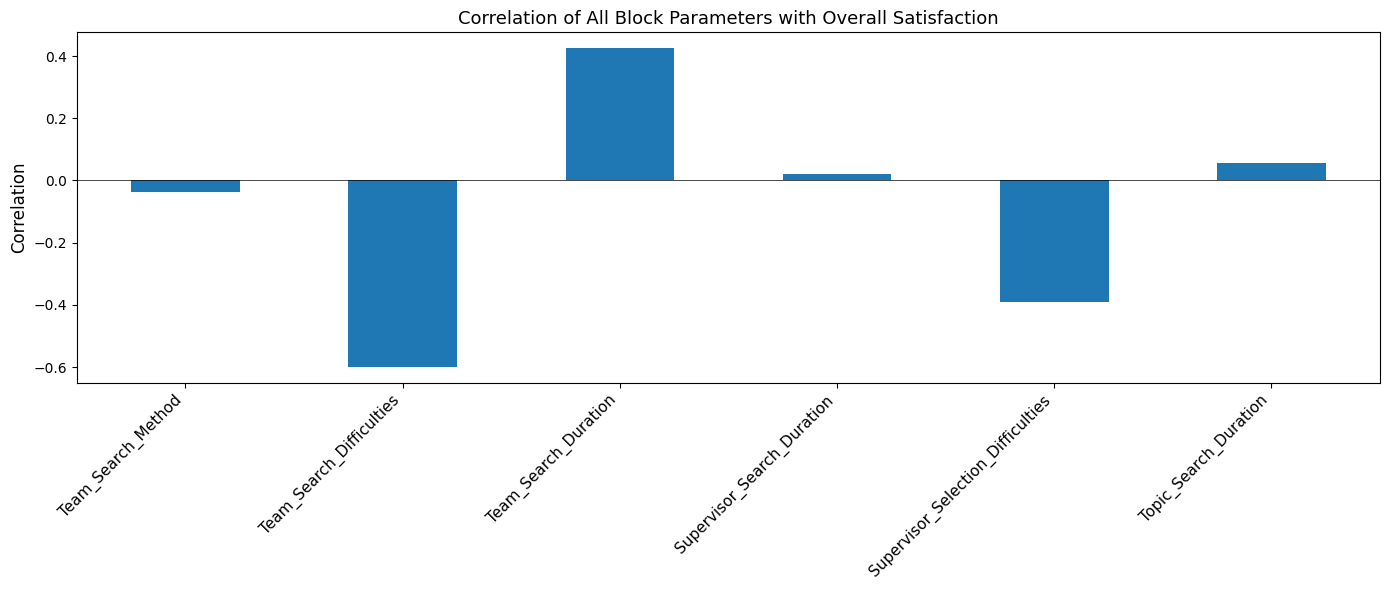

Team_Search_Method                  -0.036965
Team_Search_Difficulties            -0.599052
Team_Search_Duration                 0.425211
Supervisor_Search_Duration           0.022255
Supervisor_Selection_Difficulties   -0.391510
Topic_Search_Duration                0.055363
Name: Satisfaction, dtype: float64

In [30]:
all_features = sum(students_block_features.values(), [])
satisfaction_corrs = students_blocks_score[all_features + ['Satisfaction']].corr()['Satisfaction'].drop('Satisfaction')

plt.figure(figsize=(14, 6))
satisfaction_corrs.plot(kind='bar')
plt.title("Correlation of All Block Parameters with Overall Satisfaction", fontsize=13)
plt.axhline(0, color='black', linewidth=0.5)
plt.ylabel('Correlation', fontsize=12)
plt.tick_params(axis='y', labelsize=10)  
plt.tick_params(axis='x', labelsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('students_correlation_overall.png', dpi=300)
plt.show()

display(satisfaction_corrs)

In [31]:
supervisors_block_features = {
    'Team_Satisfaction': [
        'Teamwork_Difficulties', 'Team_Acceptance_Criteria',
        'Student_Interaction_Issues', 'Profile_Strictness'
    ],
    'Supervisor_Satisfaction': [
        'Student_Choice_Factors', 'Student_Choice_Factors', 
        'Overload_Level', 'Improvement_Suggestions'
    ],
    'Topic_Satisfaction': ['Topic_Criteria']
}					

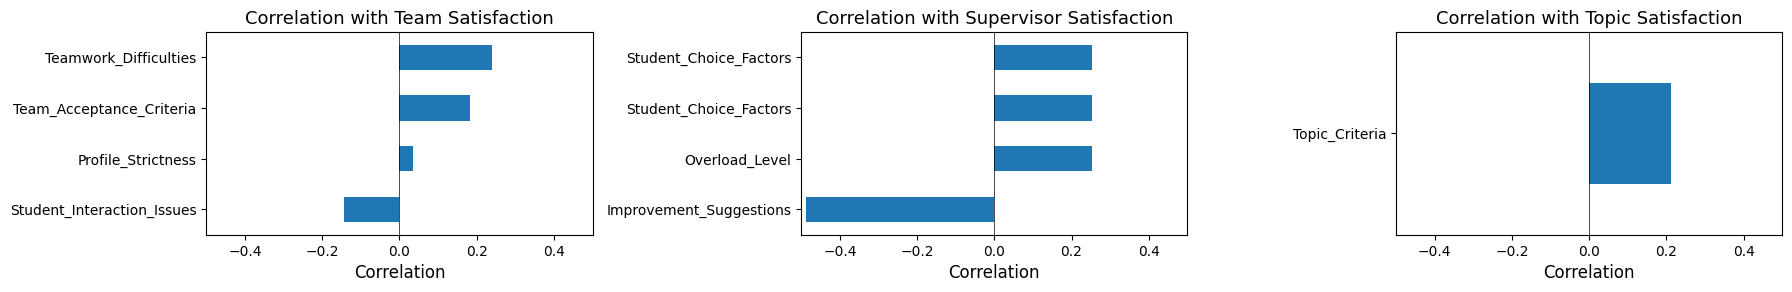

Team Satisfaction:
Teamwork_Difficulties: 0.239
Team_Acceptance_Criteria: 0.184
Profile_Strictness: 0.034
Student_Interaction_Issues: -0.144

Supervisor Satisfaction:
Student_Choice_Factors: 0.252
Student_Choice_Factors: 0.252
Overload_Level: 0.252
Improvement_Suggestions: -0.487

Topic Satisfaction:
Topic_Criteria: 0.212



In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 3), sharey=False)
for ax, (target, features) in zip(axes, supervisors_block_features.items()):
    corrs = supervisors_blocks_score[features + [target]].corr()[target].drop(target)
    corrs.sort_values().plot(kind='barh', ax=ax, width=0.5)
    ax.set_title(f"Correlation with {target.replace('_', ' ')}", fontsize=13)
    ax.set_xlim(-0.5, 0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Correlation', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)  
    ax.tick_params(axis='x', labelsize=10)
plt.tight_layout(pad=1) 
plt.savefig('supervisors_correlation_blocks.png', dpi=300)
plt.show()

for target, features in supervisors_block_features.items():
    corrs = supervisors_blocks_score[features + [target]].corr()[target].drop(target).sort_values(ascending=False)
    
    print(f"{target.replace('_', ' ')}:")
    for param, val in corrs.items():
        print(f"{param}: {val:.3f}")
    print()    

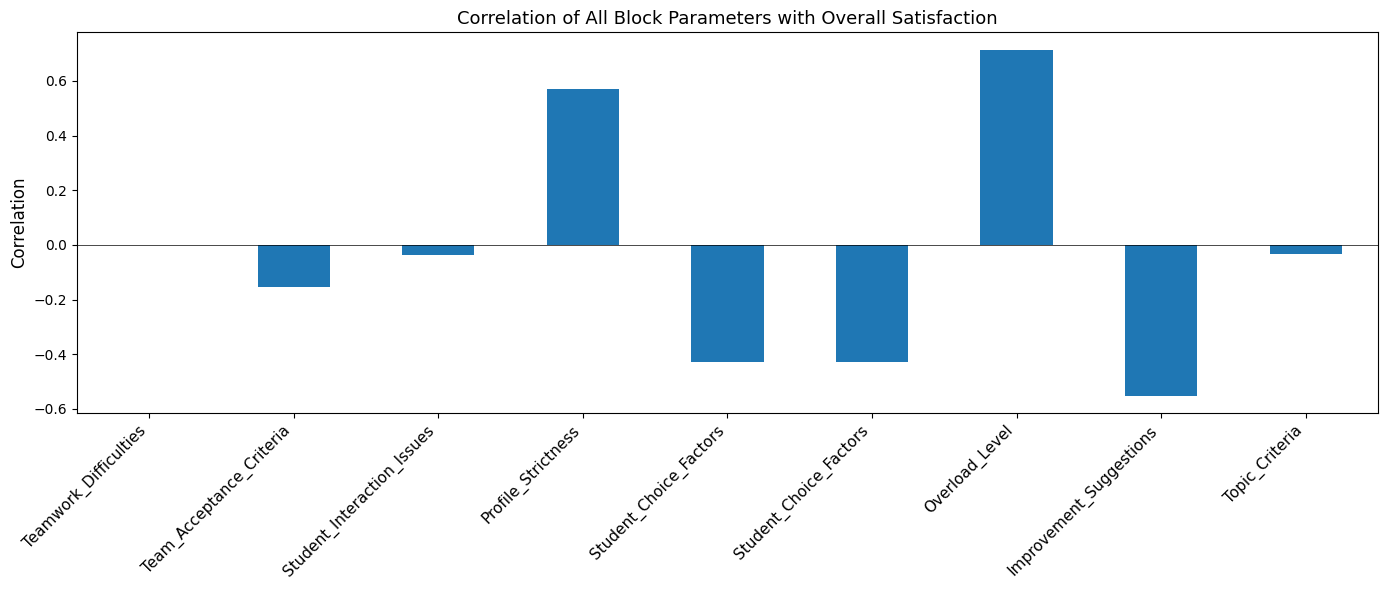

Teamwork_Difficulties         1.483598e-16
Team_Acceptance_Criteria     -1.543033e-01
Student_Interaction_Issues   -3.724195e-02
Profile_Strictness            5.698029e-01
Student_Choice_Factors       -4.285714e-01
Student_Choice_Factors       -4.285714e-01
Overload_Level                7.142857e-01
Improvement_Suggestions      -5.516773e-01
Topic_Criteria               -3.464795e-02
Name: Satisfaction, dtype: float64

In [33]:
all_features = sum(supervisors_block_features.values(), [])
satisfaction_corrs = supervisors_blocks_score[all_features + ['Satisfaction']].corr()['Satisfaction'].drop('Satisfaction')

plt.figure(figsize=(14, 6))
satisfaction_corrs.plot(kind='bar')
plt.title("Correlation of All Block Parameters with Overall Satisfaction", fontsize=13)
plt.axhline(0, color='black', linewidth=0.5)
plt.ylabel('Correlation', fontsize=12)
plt.tick_params(axis='y', labelsize=10)  
plt.tick_params(axis='x', labelsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('supervisors_correlation_overall.png', dpi=300)
plt.show()

display(satisfaction_corrs)

In [34]:
students_blocks = {
    'Team_Satisfaction': [
        'Team_Search_Method', 'Team_Search_Difficulties',
        'Team_Initiative', 'Team_Criteria', 'Team_Search_Duration'
    ],
    'Supervisor_Satisfaction': [
        'Supervisor_Search_Method', 'Supervisor_Selection_Difficulties',
        'Supervisor_Search_Duration'
    ],
    'Topic_Satisfaction': ['Topic_Search_Duration'],
    'Satisfaction': [
        'Team_Satisfaction', 'Supervisor_Satisfaction', 'Topic_Satisfaction'
    ]
}

In [35]:
supervisors_block = {
    'Supervisor_Satisfaction': [
        'Student_Choice_Factors', 'Supervisor_Selection_Difficulties',
        'Overload_Level', 'Improvement_Suggestions' 
    ],
    'Topic_Satisfaction': [
        'Topic_Criteria', 'Topic_Selection_Preference',
        'Profile_Strictness'
    ],
    'Team_Satisfaction': [
        'Teamwork_Difficulties', 'Team_Acceptance_Criteria',
        'Student_Interaction_Issues'
    ],
    'Satisfaction': [
        'Supervisor_Satisfaction', 'Topic_Satisfaction', 'Team_Satisfaction'
    ]
}			

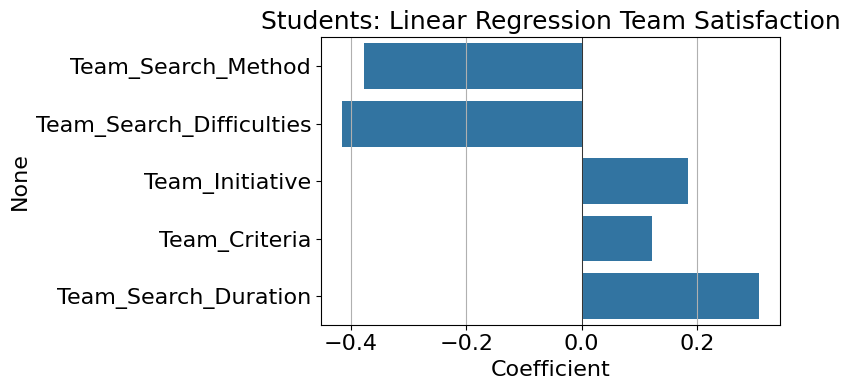

,Coefficient,P-Value
Team_Search_Method,-0.377,0.656
Team_Search_Difficulties,-0.416,0.124
Team_Initiative,0.184,0.094
Team_Criteria,0.123,0.094
Team_Search_Duration,0.308,0.202


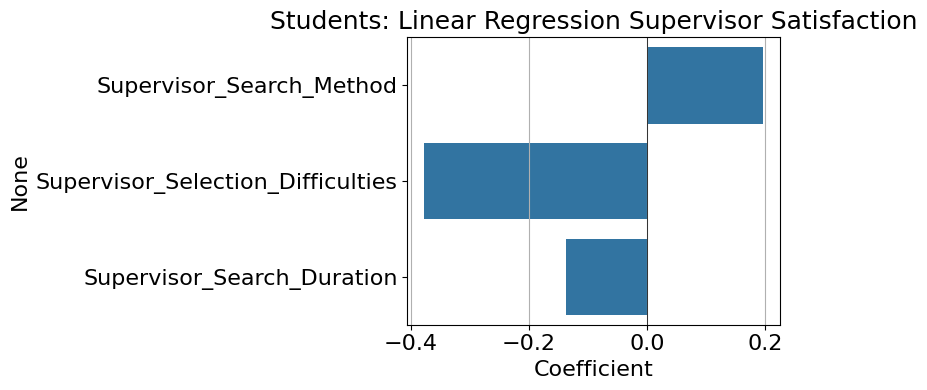

,Coefficient,P-Value
Supervisor_Search_Method,0.196,0.000
Supervisor_Selection_Difficulties,-0.377,0.019
Supervisor_Search_Duration,-0.138,0.274


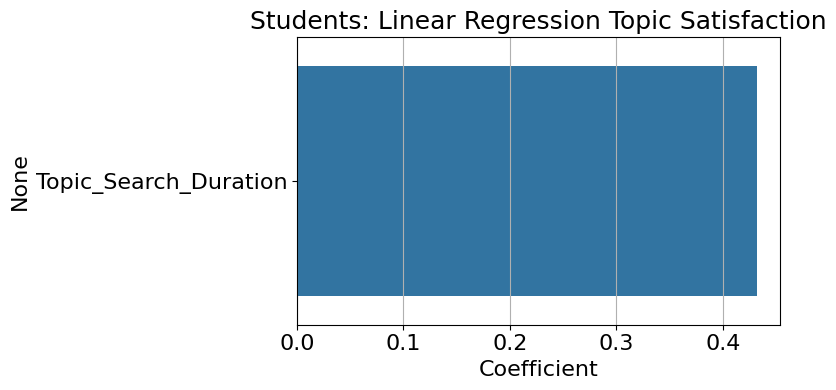

,Coefficient,P-Value
Topic_Search_Duration,0.432,0.006


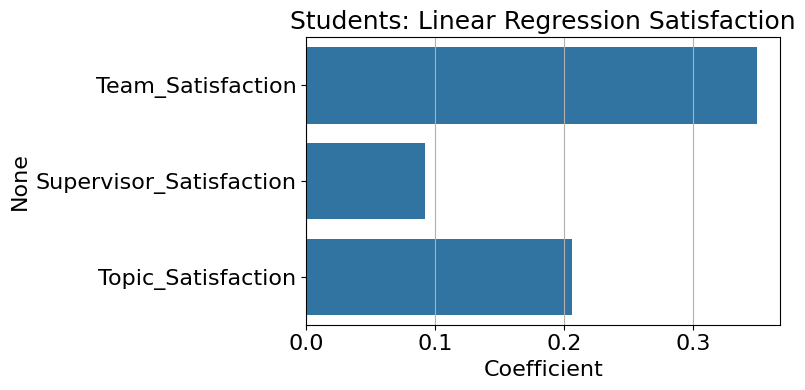

,Coefficient,P-Value
Team_Satisfaction,0.350,0.040
Supervisor_Satisfaction,0.092,0.746
Topic_Satisfaction,0.206,0.427


In [46]:
def run_block_regression_safe(data, blocks, title_prefix=''):
    for target, features in blocks.items():
        X = data[features]
        y = data[target]
        X = sm.add_constant(X, has_constant='add')
        model = sm.OLS(y, X).fit()
        summary_df = model.params.to_frame(name='Coefficient')
        summary_df['P-Value'] = model.pvalues
        summary_df = summary_df.round(3)

        # Визуализация
        plot_df = summary_df.drop(index='const', errors='ignore')
        plt.figure(figsize=(8, 4))
        sns.barplot(x=plot_df['Coefficient'], y=plot_df.index)
        plt.title(f'{title_prefix}Linear Regression {target.replace("_", " ")}')
        plt.xlabel('Coefficient')
        plt.axvline(0, color='black', linewidth=0.5)
        plt.grid(True, axis='x')
        plt.tight_layout()
        plt.savefig('students_linreg.png', dpi=300)
        plt.show()

        display(plot_df)

# Повторный запуск для студентов
run_block_regression_safe(students_blocks_score, students_blocks, title_prefix="Students: ")


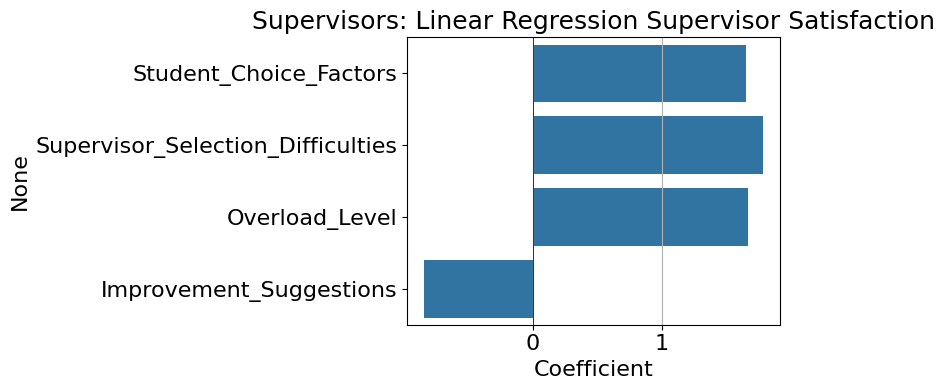

,Coefficient,P-Value
Student_Choice_Factors,1.648,0.473
Supervisor_Selection_Difficulties,1.782,0.159
Overload_Level,1.665,0.098
Improvement_Suggestions,-0.838,0.541


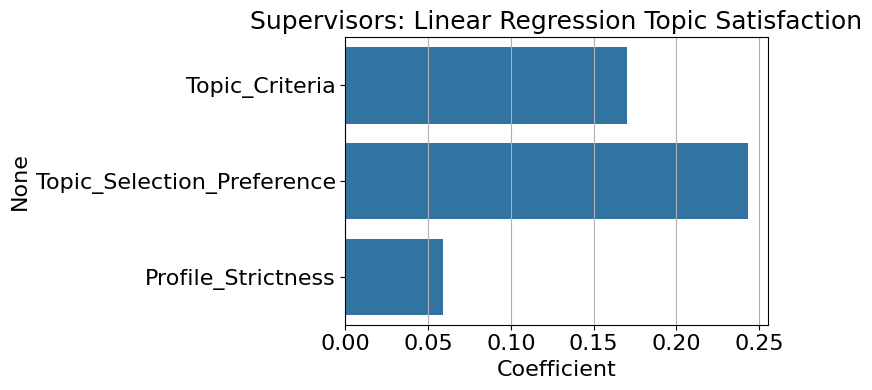

,Coefficient,P-Value
Topic_Criteria,0.170,0.728
Topic_Selection_Preference,0.243,0.088
Profile_Strictness,0.059,0.819


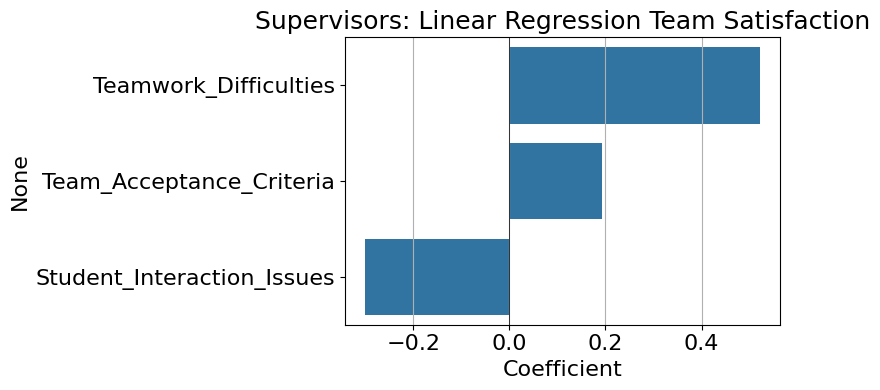

,Coefficient,P-Value
Teamwork_Difficulties,0.522,0.673
Team_Acceptance_Criteria,0.192,0.848
Student_Interaction_Issues,-0.301,0.615


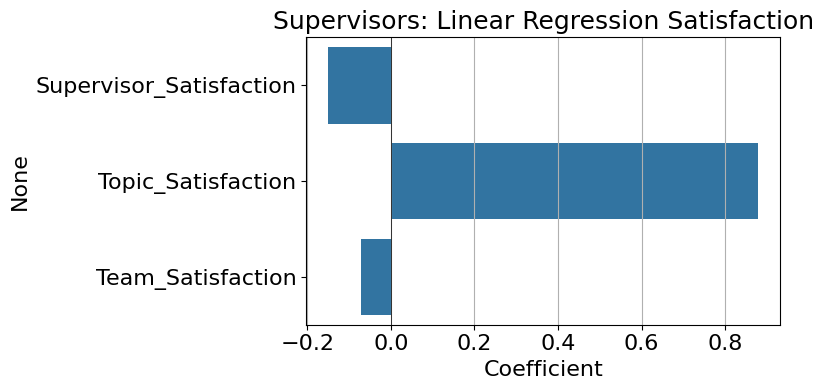

,Coefficient,P-Value
Supervisor_Satisfaction,-0.151,0.831
Topic_Satisfaction,0.880,0.464
Team_Satisfaction,-0.071,0.908


In [64]:
def run_block_regression_safe(data, blocks, title_prefix=''):
    for target, features in blocks.items():
        X = data[features]
        y = data[target]
        X = sm.add_constant(X, has_constant='add')
        model = sm.OLS(y, X).fit()
        summary_df = model.params.to_frame(name='Coefficient')
        summary_df['P-Value'] = model.pvalues
        summary_df = summary_df.round(3)

        # Визуализация
        plot_df = summary_df.drop(index='const', errors='ignore')
        plt.figure(figsize=(8, 4))
        sns.barplot(x=plot_df['Coefficient'], y=plot_df.index)
        plt.title(f'{title_prefix}Linear Regression {target.replace("_", " ")}')
        plt.xlabel('Coefficient')
        plt.axvline(0, color='black', linewidth=0.5)
        plt.grid(True, axis='x')
        plt.tight_layout()
        plt.savefig('supervisors_linreg.png', dpi=300)
        plt.show()

        display(plot_df)

# Повторный запуск для студентов
run_block_regression_safe(supervisors_blocks_score, supervisors_block, title_prefix="Supervisors: ")


Optimization terminated successfully.
         Current function value: 0.559666
         Iterations 5


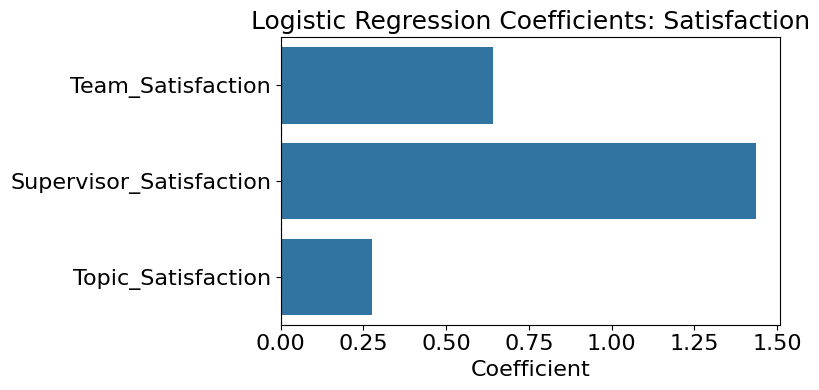

In [54]:
students_logit_df = students_blocks_score.copy()

students_logit_df['Team_Satisfaction'] = (students_logit_df['Team_Satisfaction'] >= 0.5).astype(int)
students_logit_df['Supervisor_Satisfaction'] = (students_logit_df['Supervisor_Satisfaction'] >= 0.5).astype(int)
students_logit_df['Topic_Satisfaction'] = (students_logit_df['Topic_Satisfaction'] >= 0.5).astype(int)
students_logit_df['Satisfaction'] = (students_logit_df['Satisfaction'] >= 0.5).astype(int)

X = students_logit_df[['Team_Satisfaction', 'Supervisor_Satisfaction', 'Topic_Satisfaction']]
X = sm.add_constant(X)  # Добавляем константу
y = students_logit_df['Satisfaction']

logit_model = sm.Logit(y, X).fit()
summary_df = logit_model.summary2().tables[1].round(3)

plt.figure(figsize=(8, 4))
coef_plot = summary_df.loc[summary_df.index != 'const'].copy()
coef_plot['Coef'] = coef_plot['Coef.']
coef_plot['Feature'] = coef_plot.index

sns.barplot(data=coef_plot, y='Feature', x='Coef')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression Coefficients: Satisfaction')
plt.xlabel('Coefficient')
plt.ylabel('')
plt.tight_layout()
plt.savefig('students_logreg.png', dpi=300)
plt.show()


         Current function value: 0.346574
         Iterations: 35


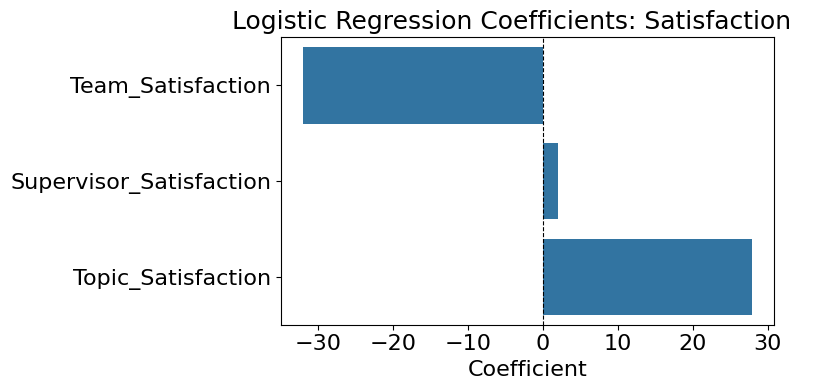

In [56]:
supervisors_logit_df = supervisors_blocks_score.copy()

supervisors_logit_df['Team_Satisfaction'] = (supervisors_logit_df['Team_Satisfaction'] >= 0.5).astype(int)
supervisors_logit_df['Supervisor_Satisfaction'] = (supervisors_logit_df['Supervisor_Satisfaction'] >= 0.5).astype(int)
supervisors_logit_df['Topic_Satisfaction'] = (supervisors_logit_df['Topic_Satisfaction'] >= 0.5).astype(int)
supervisors_logit_df['Satisfaction'] = (supervisors_logit_df['Satisfaction'] >= 0.5).astype(int)

X = supervisors_logit_df[['Team_Satisfaction', 'Supervisor_Satisfaction', 'Topic_Satisfaction']]
X = sm.add_constant(X)  
y = supervisors_logit_df['Satisfaction']

logit_model = sm.Logit(y, X).fit()
summary_df = logit_model.summary2().tables[1].round(3)

plt.figure(figsize=(8, 4))
coef_plot = summary_df.loc[summary_df.index != 'const'].copy()
coef_plot['Coef'] = coef_plot['Coef.']
coef_plot['Feature'] = coef_plot.index

sns.barplot(data=coef_plot, y='Feature', x='Coef')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression Coefficients: Satisfaction    ')
plt.xlabel('Coefficient')
plt.ylabel('')
plt.tight_layout()
plt.savefig('supervisors_logreg.png', dpi=300)
plt.show()


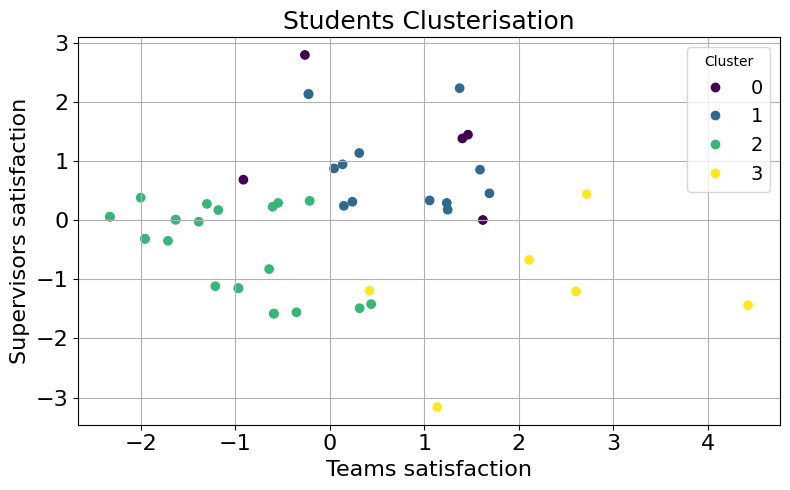

,Number of Students,Average satisfaction
Cluster,,
0,5,0.500000
1,13,0.307692
2,23,0.717391
3,6,0.416667


In [60]:
features_for_clustering = [
    'Team_Search_Method', 'Team_Search_Difficulties', 'Team_Initiative', 'Team_Search_Duration', 'Team_Criteria',
    'Supervisor_Search_Duration', 'Supervisor_Search_Method', 'Supervisor_Selection_Difficulties',
    'Topic_Search_Duration'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(students_blocks_score[features_for_clustering])

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
students_blocks_score['PCA1'] = pca_coords[:, 0]
students_blocks_score['PCA2'] = pca_coords[:, 1]

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
students_blocks_score['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    students_blocks_score['PCA1'],
    students_blocks_score['PCA2'],
    c=students_blocks_score['Cluster'],
    cmap='viridis'
)

plt.title("Students Clusterisation")
plt.xlabel("Teams satisfaction")
plt.ylabel("Supervisors satisfaction")
plt.grid(True)
plt.tight_layout()
plt.savefig('students_clasterisation.png', dpi=300)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# Анализ удовлетворенности по кластерам
cluster_summary = students_blocks_score.groupby('Cluster')['Satisfaction'].agg(['count', 'mean']).rename(columns={
    'count': 'Number of Students',
    'mean': 'Average satisfaction'
})

display(cluster_summary)



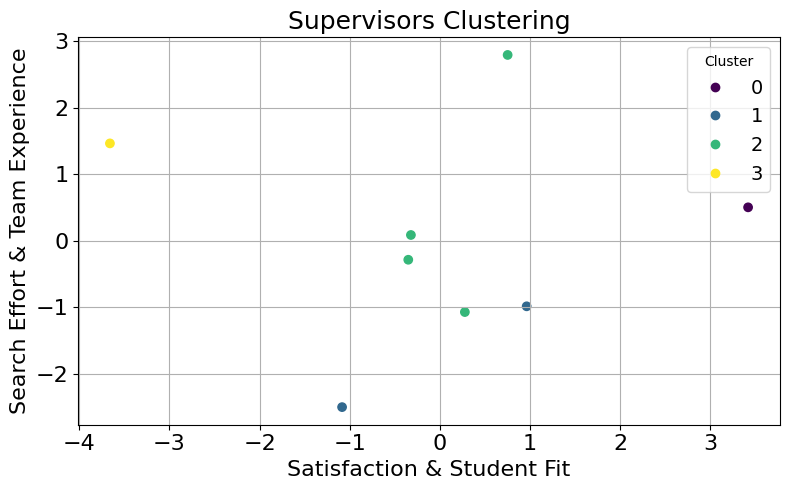

,Number of Supervisors,Average Satisfaction
Cluster,,
0,1,0.50
1,2,0.75
2,4,0.25
3,1,0.00


In [61]:
features_supervisors = [
    'Student_Choice_Factors', 'Supervisor_Selection_Difficulties', 'Overload_Level',
    'Topic_Criteria', 'Topic_Selection_Preference', 'Profile_Strictness',
    'Improvement_Suggestions', 'Teamwork_Difficulties',
    'Team_Acceptance_Criteria', 'Student_Interaction_Issues'
]

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(supervisors_blocks_score[features_supervisors])

# PCA
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
supervisors_blocks_score['PCA1'] = pca_coords[:, 0]
supervisors_blocks_score['PCA2'] = pca_coords[:, 1]

# Кластеризация
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
supervisors_blocks_score['Cluster'] = kmeans.fit_predict(X_scaled)

# Визуализация
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    supervisors_blocks_score['PCA1'],
    supervisors_blocks_score['PCA2'],
    c=supervisors_blocks_score['Cluster'],
    cmap='viridis'
)
plt.title("Supervisors Clustering")
plt.xlabel("Satisfaction & Student Fit")
plt.ylabel("Search Effort & Team Experience")
plt.grid(True)
plt.tight_layout()
plt.savefig('supervisors_clasterisation.png', dpi=300)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# Сводка по кластерам
cluster_summary = supervisors_blocks_score.groupby('Cluster')['Satisfaction'].agg(['count', 'mean']).rename(columns={
    'count': 'Number of Supervisors',
    'mean': 'Average Satisfaction'
})

display(cluster_summary)
